In [ ]:
# Cell 1: Install and imports
!pip install -q nltk scikit-learn matplotlib seaborn

import os
import sys
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

print("Imports done.")



Imports done.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
!pip install -q datasets nltk scikit-learn


In [ ]:
!rm -f Fake.csv
!rm -f True.csv


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Fake.csv to Fake.csv
Saving True.csv to True.csv


In [ ]:
import os
print(os.listdir())



['.config', 'Fake.csv', 'True.csv', 'sample_data']


In [ ]:
import pandas as pd

fake = pd.read_csv("Fake.csv")
real = pd.read_csv("True.csv")

print(fake.head())
print(real.head())


                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  
0  December 31, 2017  
1  December 31, 2017  
2  December 30, 2017  
3  December 29, 2017  
4  December 25, 2017  
                                               title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept t

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Label data
fake["label"] = 0
real["label"] = 1

# Combine
data = pd.concat([fake, real], axis=0)
data = data.sample(frac=1).reset_index(drop=True)

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean_text(text):
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^A-Za-z ]+", "", text)
    text = text.lower()
    words = text.split()
    words = [stemmer.stem(word) for word in words if word not in stop_words]
    return " ".join(words)

data["content"] = data["title"] + " " + data["text"]
data["clean"] = data["content"].apply(clean_text)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    data["clean"], data["label"], test_size=0.2, random_state=42
)

from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=200)
model.fit(X_train_vec, y_train)

from sklearn.metrics import accuracy_score, classification_report
pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Accuracy: 0.9875278396436525
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4650
           1       0.98      0.99      0.99      4330

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



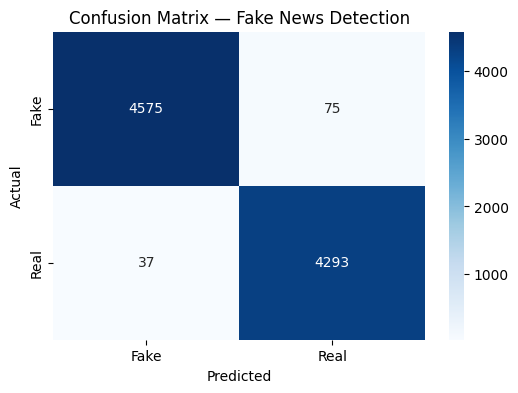

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fake","Real"],
            yticklabels=["Fake","Real"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Fake News Detection")
plt.show()



In [ ]:
def predict_news(text):
    cleaned = clean_text(text)
    vector = vectorizer.transform([cleaned])
    pred = model.predict(vector)[0]
    prob = model.predict_proba(vector)[0][pred]
    label = "REAL" if pred == 1 else "FAKE"
    return label, round(prob*100,2)

# Example
print(predict_news("NASA announces discovery of new planet"))


('FAKE', np.float64(88.38))


In [ ]:
import joblib
joblib.dump(model, "fake_news_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")


['tfidf_vectorizer.pkl']